# Question 4: Apply Regression-Free Forecasting (Trend Extrapolation & Smoothing)

# Step 1 - Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 2 - Load Dataset

In [2]:
df = pd.read_csv("traffic_data_for_datascience.csv")

# Step 3 - Convert Timestamp Column

In [3]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Step 4 - Sort Data by Time

In [4]:
df = df.sort_values('Timestamp')

# Step 5 - Create Weekly Average Traffic Data

In [5]:
weekly_data = df.resample('W', on='Timestamp')['Traffic_Volume'].mean().reset_index()

# Step 6 - Apply Moving Average Smoothing

In [6]:
weekly_data['Moving_Average'] = weekly_data['Traffic_Volume'].rolling(window=2).mean()

# Step 7 - View Forecast Data

In [7]:
weekly_data[['Timestamp',
             'Traffic_Volume',
             'Moving_Average']].head(10)

,Timestamp,Traffic_Volume,Moving_Average
0,2024-01-07,67.571759,NaN
1,2024-01-14,67.961640,67.766700
2,2024-01-21,67.919974,67.940807
3,2024-01-28,68.609127,68.264550
4,2024-02-04,68.943122,68.776124
5,2024-02-11,69.600529,69.271825
6,2024-02-18,69.786706,69.693618
7,2024-02-25,70.101521,69.944114
8,2024-03-03,70.309193,70.205357
9,2024-03-10,70.638889,70.474041


# Step 8 - Plot Forecast Graph

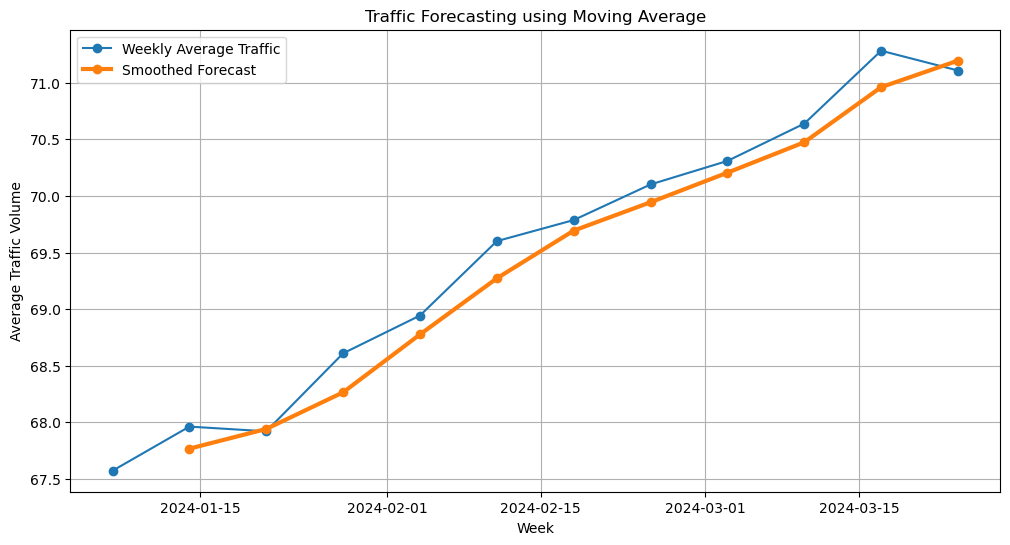

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    weekly_data['Timestamp'],
    weekly_data['Traffic_Volume'],
    marker='o',
    label='Weekly Average Traffic'
)

plt.plot(
    weekly_data['Timestamp'],
    weekly_data['Moving_Average'],
    marker='o',
    linewidth=3,
    label='Smoothed Forecast'
)

plt.xlabel("Week")
plt.ylabel("Average Traffic Volume")

plt.title("Traffic Forecasting using Moving Average")

plt.legend()

plt.grid(True)

plt.show()